In [66]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv
/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv


In [67]:
df = pd.read_csv('/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv')

In [68]:
df.sample(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
96,97,306,100,2,3.0,3.0,8.00,0,0.48
146,147,315,105,3,2.0,2.5,8.48,0,0.75
55,56,320,103,3,3.0,3.0,7.70,0,0.64
189,190,324,112,5,5.0,5.0,9.08,1,0.88
299,300,305,112,3,3.0,3.5,8.65,0,0.71


In [69]:
df.shape

(500, 9)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df.drop(columns=['Serial No.'],inplace = True)

In [73]:
X = df.iloc[:,0:7]
y = df.iloc[:,-1]

In [74]:
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [75]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [76]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
238,310,104,3,2.0,3.5,8.37,0
438,318,110,1,2.5,3.5,8.54,1
475,300,101,3,3.5,2.5,7.88,0
58,300,99,1,3.0,2.0,6.80,1
380,322,104,3,3.5,4.0,8.84,1
...,...,...,...,...,...,...,...
255,307,110,4,4.0,4.5,8.37,0
72,321,111,5,5.0,5.0,9.45,1
396,325,107,3,3.0,3.5,9.11,1
235,326,111,5,4.5,4.0,9.23,1


In [77]:
from sklearn.preprocessing import MinMaxScaler

In [78]:
scale = MinMaxScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

In [79]:
X_train_scaled

array([[0.4       , 0.42857143, 0.5       , ..., 0.57142857, 0.50320513,
        0.        ],
       [0.56      , 0.64285714, 0.        , ..., 0.57142857, 0.55769231,
        1.        ],
       [0.2       , 0.32142857, 0.5       , ..., 0.28571429, 0.34615385,
        0.        ],
       ...,
       [0.7       , 0.53571429, 0.5       , ..., 0.57142857, 0.74038462,
        1.        ],
       [0.72      , 0.67857143, 1.        , ..., 0.71428571, 0.77884615,
        1.        ],
       [0.2       , 0.46428571, 0.        , ..., 0.14285714, 0.32051282,
        0.        ]])

In [80]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [81]:
model = Sequential()
model.add(Dense(10,activation = 'relu',input_dim = 7))
model.add(Dense(1,activation = 'linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

In [83]:
model.compile(loss = 'mean_squared_error',optimizer = 'Adam',metrics = ['r2_score'])

In [84]:
history=model.fit(X_train_scaled,y_train,epochs=120,validation_split = 0.2)

Epoch 1/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0699 - r2_score: -2.3021 - val_loss: 0.0685 - val_r2_score: -3.8144
Epoch 2/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0576 - r2_score: -1.7219 - val_loss: 0.0593 - val_r2_score: -3.1674
Epoch 3/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0491 - r2_score: -1.3184 - val_loss: 0.0513 - val_r2_score: -2.6105
Epoch 4/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0430 - r2_score: -1.0334 - val_loss: 0.0457 - val_r2_score: -2.2134
Epoch 5/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0383 - r2_score: -0.8085 - val_loss: 0.0411 - val_r2_score: -1.8919
Epoch 6/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0345 - r2_score: -0.6306 - val_loss: 0.0374 - val_r2_score: -1.6301
Epoch 7/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0312 - r2_score: -0.4735 - val_loss: 0.0339 - val_r2_score: -1.3867
Epoch 8/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0282 - r2_score: -0.3344 - v

In [85]:
 y_pred = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [86]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8109941477752796

In [87]:
import matplotlib.pyplot as plt

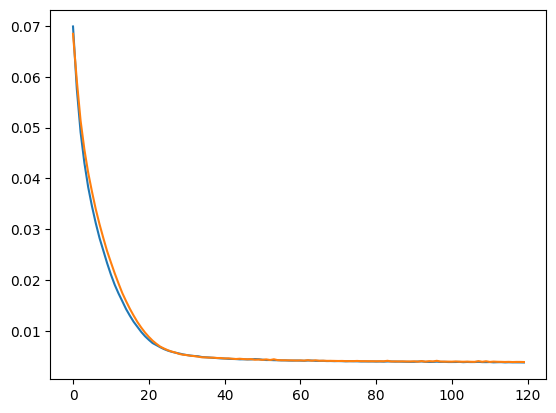

In [88]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

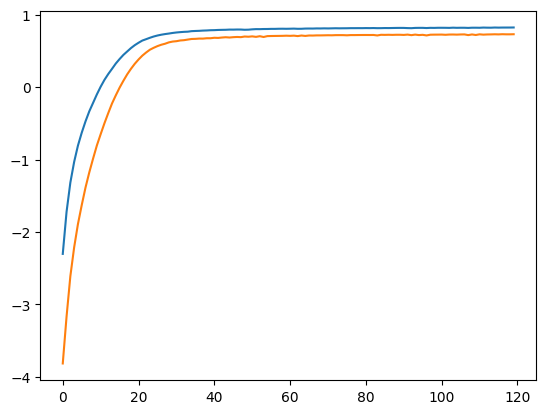

In [89]:
plt.plot(history.history['r2_score'])
plt.plot(history.history['val_r2_score'])